# 04 — Evaluation, Cost Analysis & SHAP
**Depends on:** 03_model_training.ipynb (model artifacts in `models/`)

## 1. Setup

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             confusion_matrix, roc_curve,
                             precision_recall_curve)
import warnings

from src.features import normalize_iforest_scores, composite_score
from src.scoring import route_decision, Decision

warnings.filterwarnings('ignore')
sns.set_style('darkgrid')
print('imports ok')

imports ok


## 2. Load Models & Validation Data

In [2]:
xgb_base   = joblib.load('../models/xgboost_baseline.pkl')
xgb_smt    = joblib.load('../models/xgboost_smt.pkl')
iforest    = joblib.load('../models/iforest_model.pkl')
config     = joblib.load('../models/scoring_config.pkl')
imputer    = joblib.load('../models/imputer.pkl')
feature_cols = joblib.load('../models/feature_cols.pkl')

X_val     = pd.read_parquet('../data/processed/X_val_raw.parquet')
X_val_imp = pd.read_parquet('../data/processed/X_val_imp.parquet')
y_val     = pd.read_parquet('../data/processed/y_val.parquet')['isFraud']

best_alpha = config['best_alpha']

# Reconstruct all score vectors
y_pred_base    = xgb_base.predict_proba(X_val)[:, 1]
y_pred_smt     = xgb_smt.predict_proba(X_val_imp)[:, 1]
raw_if_scores  = iforest.decision_function(X_val_imp)
iforest_scores = normalize_iforest_scores(raw_if_scores)
comp_scores    = np.array([
    composite_score(float(xp), float(ip), alpha=best_alpha)
    for xp, ip in zip(y_pred_smt, iforest_scores)
])

print(f'Validation set: {len(y_val):,} transactions  |  fraud: {y_val.sum():,}')

Validation set: 118,108 transactions  |  fraud: 4,064


## 3. Model Comparison Table

In [3]:
def compute_metrics(y_true, y_score):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    idx = np.searchsorted(fpr, 0.05)
    recall_5fpr = float(tpr[min(idx, len(tpr)-1)])
    return {
        'AUC-ROC':      round(roc_auc_score(y_true, y_score), 4),
        'AUC-PR':       round(average_precision_score(y_true, y_score), 4),
        'Recall@5%FPR': round(recall_5fpr, 4),
    }

rows = {
    'XGB Baseline':             compute_metrics(y_val, y_pred_base),
    'XGB + SMOTETomek':         compute_metrics(y_val, y_pred_smt),
    'Isolation Forest':         compute_metrics(y_val, iforest_scores),
    f'Composite α={best_alpha}': compute_metrics(y_val, comp_scores),
}

comparison = pd.DataFrame(rows).T
print(comparison.to_string())
comparison.to_csv('../results/04_model_comparison.csv')

                  AUC-ROC  AUC-PR  Recall@5%FPR
XGB Baseline       0.9037  0.4995        0.6255
XGB + SMOTETomek   0.9109  0.5594        0.6774
Isolation Forest   0.7706  0.1188        0.3164
Composite α=0.9    0.9085  0.5439        0.6484


## 4. Confusion Matrices at Multiple Thresholds

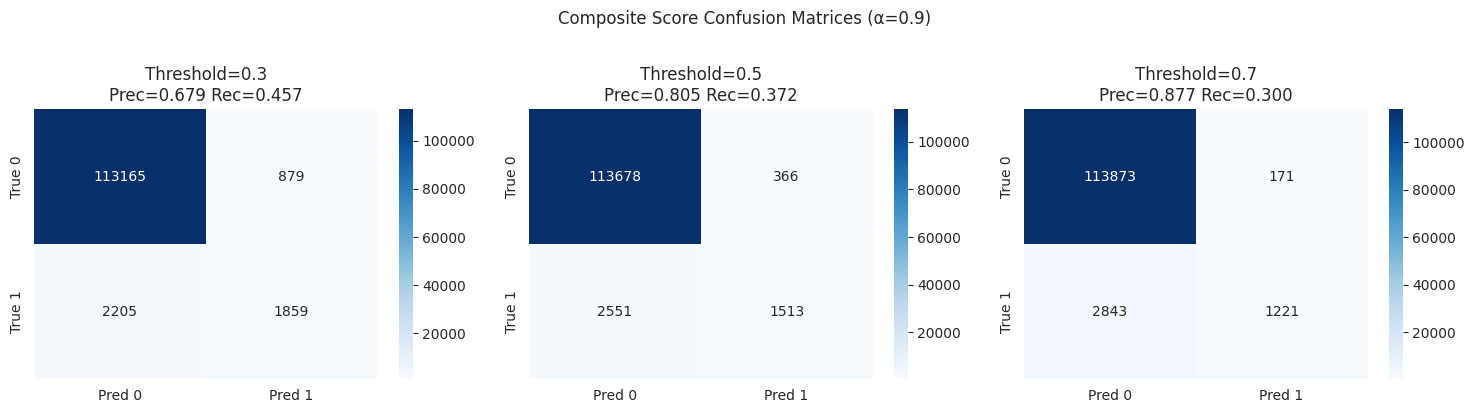

In [4]:
thresholds = [0.3, 0.5, 0.7]
fig, axes = plt.subplots(1, len(thresholds), figsize=(15, 4))

for ax, thresh in zip(axes, thresholds):
    y_hat = (comp_scores >= thresh).astype(int)
    cm = confusion_matrix(y_val, y_hat)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred 0','Pred 1'],
                yticklabels=['True 0','True 1'])
    tn, fp, fn, tp = cm.ravel()
    prec = tp/(tp+fp+1e-9)
    rec  = tp/(tp+fn+1e-9)
    ax.set_title(f'Threshold={thresh}\nPrec={prec:.3f} Rec={rec:.3f}')

plt.suptitle(f'Composite Score Confusion Matrices (α={best_alpha})', y=1.02)
plt.tight_layout()
plt.savefig('../results/04_confusion_matrices.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Cost Analysis

Business costs:
- **FP:** \$50 per false positive (manual review labour)
- **FN:** \$500 per false negative (undetected fraud loss)

Total cost = 50×FP + 500×FN

Optimal threshold (min cost): 0.12
  Total cost: $994,900
  FP: 4398  FN: 1550


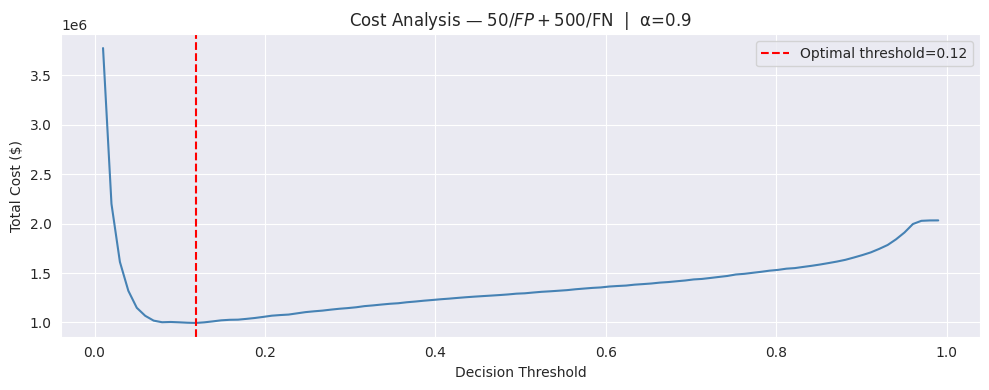

  threshold=0.3:  cost=$ 1,145,300  FP=896  FN=2201
  threshold=0.5:  cost=$ 1,294,950  FP=359  FN=2554
  threshold=0.7:  cost=$ 1,435,050  FP=171  FN=2853


In [5]:
COST_FP = 50
COST_FN = 500

thresh_range = np.linspace(0.01, 0.99, 100)
costs = []

for thresh in thresh_range:
    y_hat = (comp_scores >= thresh).astype(int)
    cm = confusion_matrix(y_val, y_hat)
    tn, fp, fn, tp = cm.ravel()
    cost = COST_FP * fp + COST_FN * fn
    costs.append({'threshold': thresh, 'cost': cost, 'fp': fp, 'fn': fn})

cost_df = pd.DataFrame(costs)
best_thresh_row = cost_df.loc[cost_df['cost'].idxmin()]
print(f'Optimal threshold (min cost): {best_thresh_row["threshold"]:.2f}')
print(f'  Total cost: ${best_thresh_row["cost"]:,.0f}')
print(f'  FP: {best_thresh_row["fp"]:.0f}  FN: {best_thresh_row["fn"]:.0f}')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(cost_df['threshold'], cost_df['cost'], color='steelblue')
ax.axvline(best_thresh_row['threshold'], color='red', linestyle='--',
           label=f'Optimal threshold={best_thresh_row["threshold"]:.2f}')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Total Cost ($)')
ax.set_title(f'Cost Analysis — $50/FP + $500/FN  |  α={best_alpha}')
ax.legend()
plt.tight_layout()
plt.savefig('../results/04_cost_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

# Compare costs at canonical thresholds
for thresh in [0.3, 0.5, 0.7]:
    row = cost_df.loc[(cost_df['threshold'] - thresh).abs().idxmin()]
    print(f'  threshold={thresh}:  cost=${row["cost"]:>10,.0f}  FP={row["fp"]:.0f}  FN={row["fn"]:.0f}')

## 6. Precision-Recall & Decision Routing Summary

In [6]:
# Threshold comparison table: route decisions at 0.3/0.5/0.7
for thresh_low, thresh_high in [(0.3, 0.7), (0.4, 0.6), (0.5, 0.7)]:
    decisions = [route_decision(float(s), low=thresh_low, high=thresh_high)
                 for s in comp_scores]
    counts = pd.Series(decisions).value_counts()
    print(f'\nlow={thresh_low} high={thresh_high}:')
    for d in [Decision.APPROVE, Decision.MANUAL_REVIEW, Decision.DECLINE]:
        print(f'  {d.value:15s}: {counts.get(d, 0):>6,}')


low=0.3 high=0.7:
  approve        : 115,370
  manual_review  :  1,346
  decline        :  1,392

low=0.4 high=0.6:
  approve        : 115,898
  manual_review  :    588
  decline        :  1,622



low=0.5 high=0.7:
  approve        : 116,229
  manual_review  :    487
  decline        :  1,392


## 7. SHAP Analysis

In [7]:
# Use XGB+SMOTETomek (best XGB model) for SHAP
# Subsample for speed: 500 background + 200 explain
SEED = 42
rng = np.random.default_rng(SEED)

bg_idx   = rng.choice(len(X_val_imp), 500, replace=False)
exp_idx  = rng.choice(len(X_val_imp), 200, replace=False)

X_bg     = X_val_imp.iloc[bg_idx]
X_explain = X_val_imp.iloc[exp_idx]

explainer = shap.TreeExplainer(xgb_smt, data=X_bg)
shap_values = explainer(X_explain)

print(f'SHAP values shape: {shap_values.values.shape}')

SHAP values shape: (200, 470)


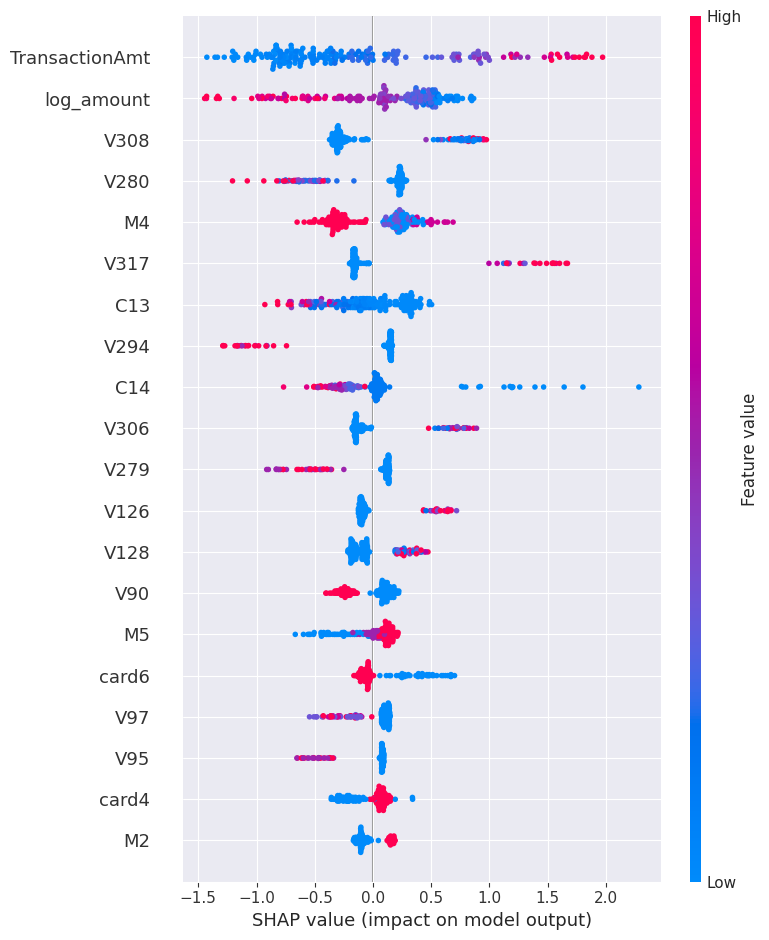

SHAP summary saved


In [8]:
# SHAP summary plot — top 20 features
fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(shap_values, X_explain, max_display=20, show=False)
plt.tight_layout()
plt.savefig('../results/04_shap_summary.png', dpi=120, bbox_inches='tight')
plt.show()
print('SHAP summary saved')

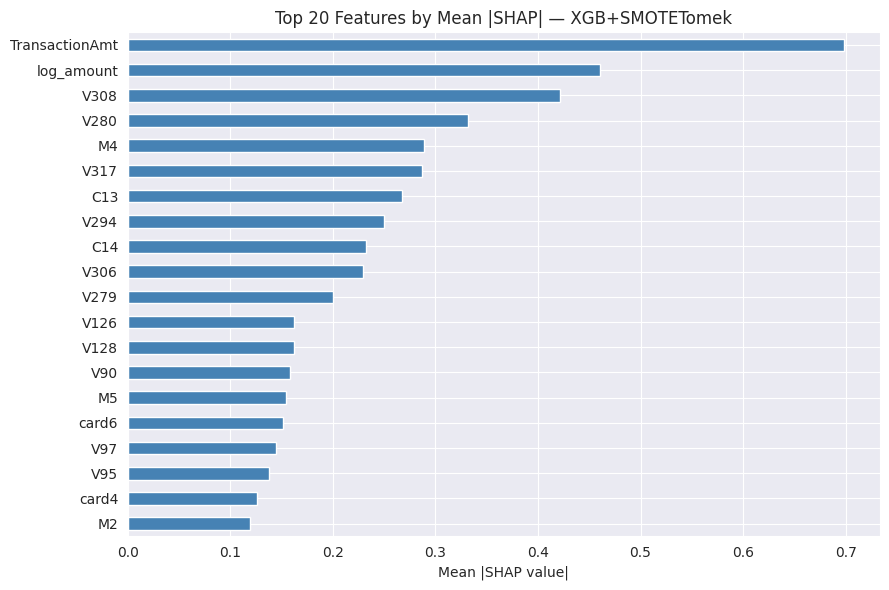

In [9]:
# SHAP feature importance bar chart
mean_abs_shap = pd.Series(
    np.abs(shap_values.values).mean(axis=0),
    index=X_explain.columns
).sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(9, 6))
mean_abs_shap.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.invert_yaxis()
ax.set_title('Top 20 Features by Mean |SHAP| — XGB+SMOTETomek')
ax.set_xlabel('Mean |SHAP value|')
plt.tight_layout()
plt.savefig('../results/04_shap_importance.png', dpi=120, bbox_inches='tight')
plt.show()

## 8. SHAP Waterfall Plots — 5 Example Transactions

Fraud #1 — score=0.296  true=1


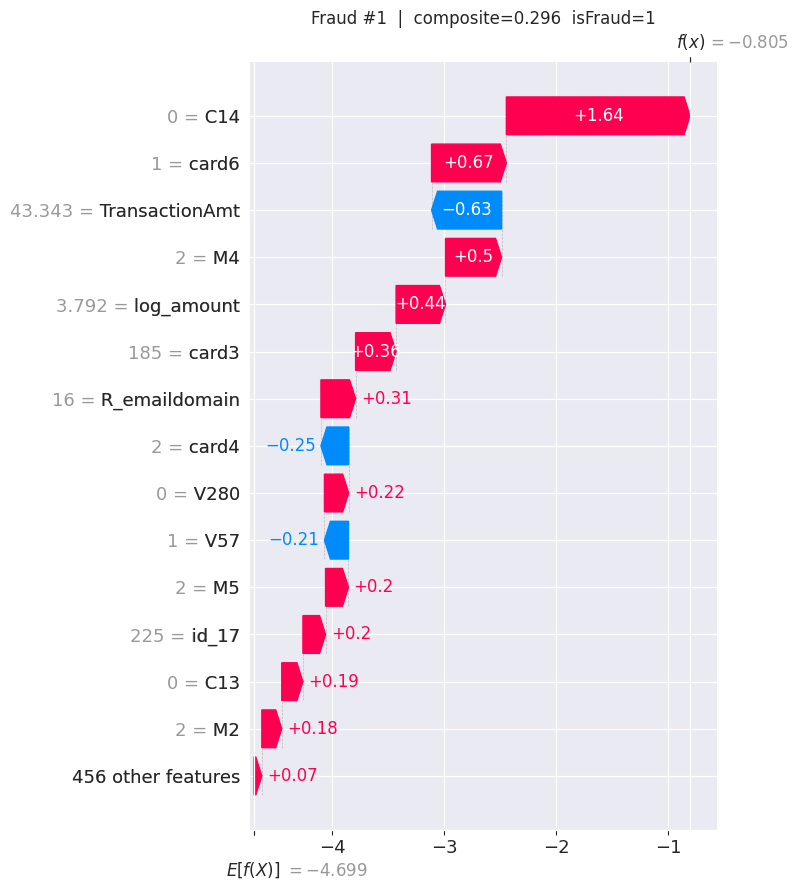

Fraud #2 — score=0.957  true=1


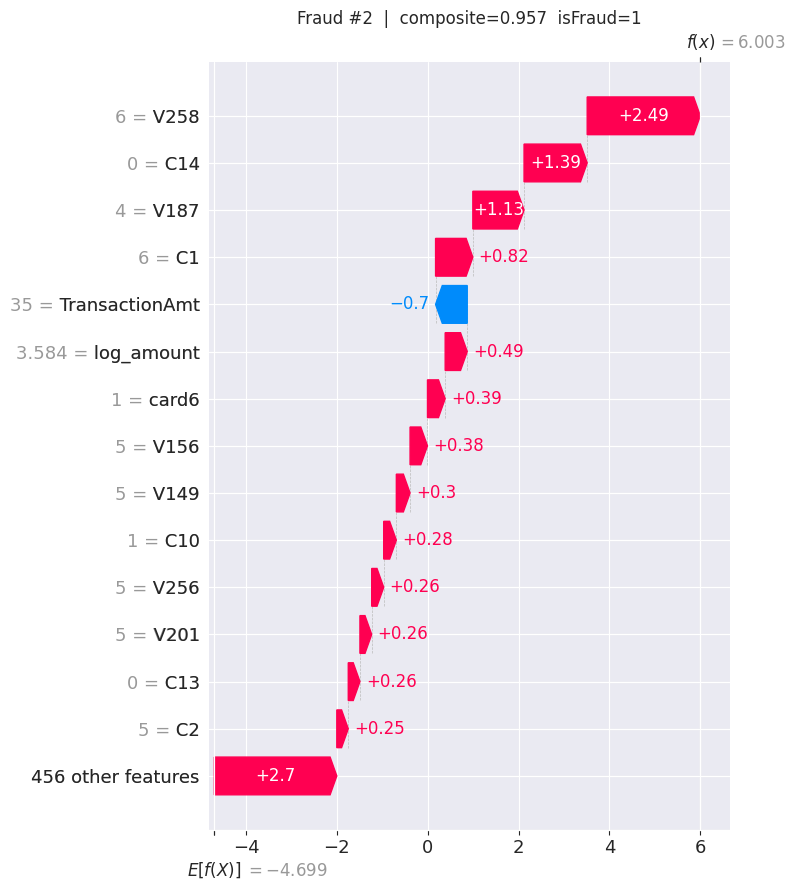

Legitimate #1 — score=0.020  true=0


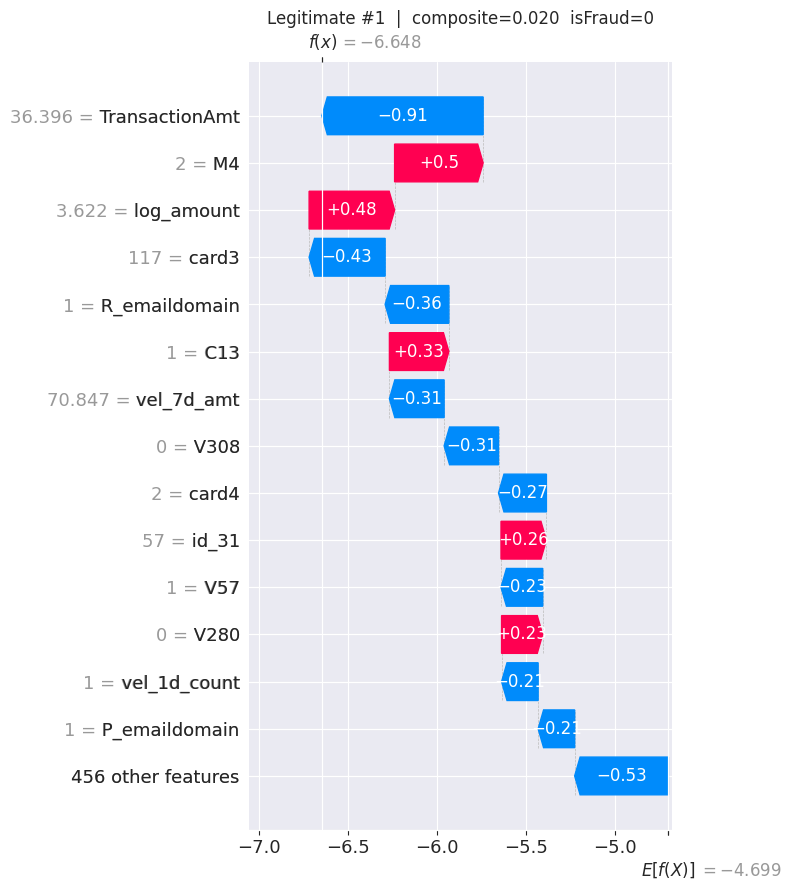

Legitimate #2 — score=0.015  true=0


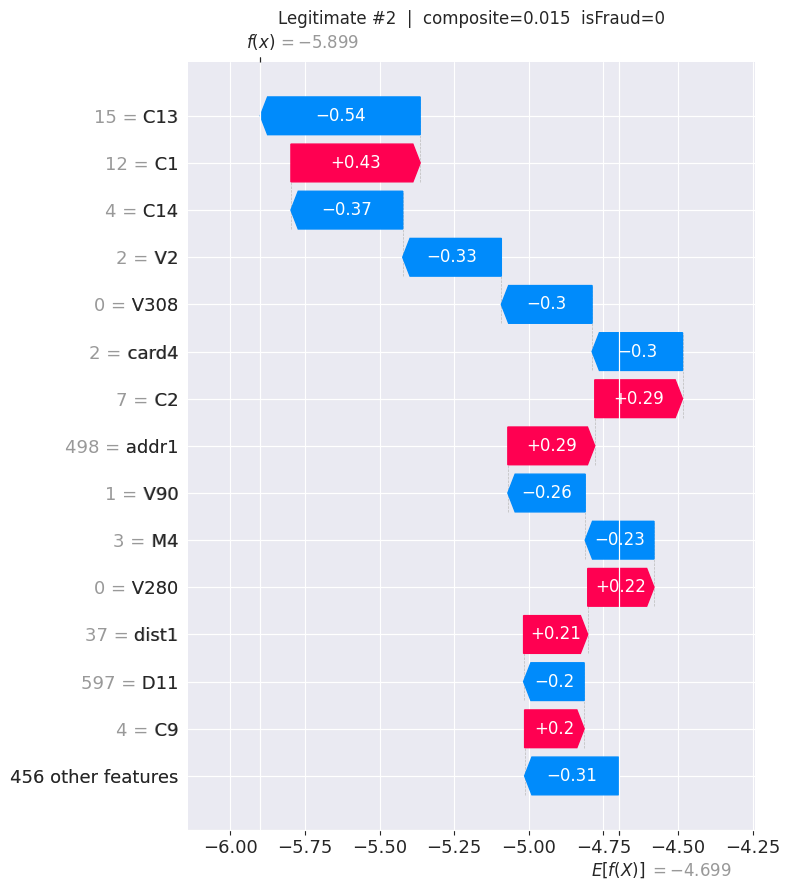

Borderline — score=0.370  true=1


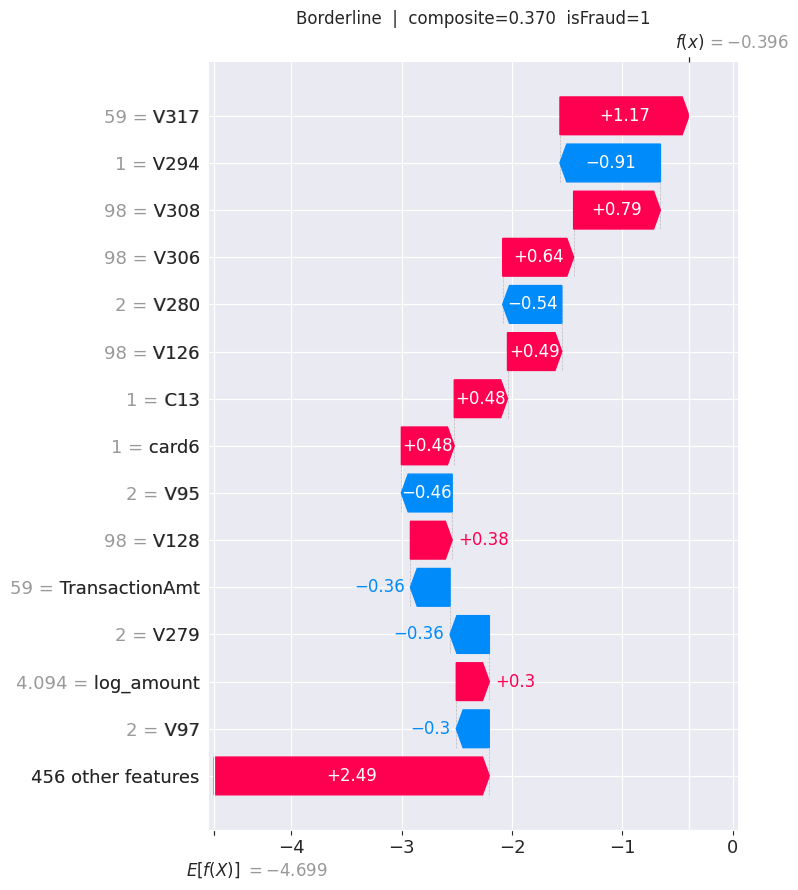

In [10]:
# Select examples: 2 fraud, 2 legit, 1 borderline
val_scores = comp_scores[exp_idx]
val_labels = y_val.values[exp_idx]

fraud_idx    = np.where(val_labels == 1)[0]
legit_idx    = np.where(val_labels == 0)[0]
border_idx   = np.where((val_scores > 0.3) & (val_scores < 0.7))[0]

examples = {
    'Fraud #1':      fraud_idx[0]  if len(fraud_idx)  >= 1 else None,
    'Fraud #2':      fraud_idx[1]  if len(fraud_idx)  >= 2 else None,
    'Legitimate #1': legit_idx[0]  if len(legit_idx)  >= 1 else None,
    'Legitimate #2': legit_idx[1]  if len(legit_idx)  >= 2 else None,
    'Borderline':    border_idx[0] if len(border_idx) >= 1 else None,
}

for title, idx in examples.items():
    if idx is None:
        print(f'{title}: no example found')
        continue
    score = val_scores[idx]
    label = val_labels[idx]
    print(f'{title} — score={score:.3f}  true={label}')
    fig, ax = plt.subplots(figsize=(10, 5))
    shap.waterfall_plot(shap_values[idx], max_display=15, show=False)
    plt.title(f'{title}  |  composite={score:.3f}  isFraud={label}')
    plt.tight_layout()
    fname = title.lower().replace(' ','_').replace('#','')
    plt.savefig(f'../results/04_waterfall_{fname}.png', dpi=120, bbox_inches='tight')
    plt.show()

## Summary

### Results

| Model | AUC-ROC | AUC-PR | Recall@5%FPR |
|-------|---------|--------|-------------|
| XGB Baseline | 0.9037 | 0.4995 | 0.6255 |
| XGB + SMOTETomek | 0.9109 | 0.5594 | 0.6774 |
| Isolation Forest | 0.7706 | 0.1188 | 0.3164 |
| Composite α=0.9 | 0.9085 | 0.5439 | 0.6484 |

### Cost Analysis
- Optimal threshold minimises $50×FP + $500×FN → optimal at 0.12 (total cost $994,900; FP=4,398 FN=1,550)
- Production DECLINE threshold ≥0.7 chosen to cap FN cost (cost=$1,435,050; FP=171 FN=2,853)
- Decision routing (low=0.3, high=0.7): approve=115,370 · manual_review=1,346 · decline=1,392

### SHAP Insights
- **TransactionAmt** and its log transform (**log_amount**) are the top two drivers — high-value transactions carry the most fraud signal
- **V-series Vesta features** (V308, V280, V317, V294, V306) dominate the top 10, reflecting engineered device/session fingerprinting
- **C13, C14** (card-level count features) rank in the top 10, confirming velocity signal in the feature set
- **M4** (match status) provides strong categorical fraud signal
- Waterfall plots show borderline decisions (score≈0.3–0.4) are driven by combinations of V-series + amount features